In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the merged dataset
data_path = '../data/processed/'
df = pd.read_csv(data_path + 'olympics_gdp_merged.csv')

print("Dataset loaded successfully!")
print(f"Total records: {len(df):,}")
print(f"Columns: {list(df.columns)}")

# Display basic info
print("\nFirst few rows:")
print(df.head())

Dataset loaded successfully!
Total records: 271,116
Columns: ['Athlete_ID', 'Athlete_Name', 'Sex', 'Age', 'Height_cm', 'Weight_kg', 'Team', 'NOC', 'Country_Name', 'Country_Code', 'Games', 'Year', 'Season', 'Host_City', 'Sport', 'Event', 'Medal', 'Medal_Won', 'Medal_Value', 'GDP_per_capita']

First few rows:
   Athlete_ID              Athlete_Name Sex   Age  Height_cm  Weight_kg  \
0           1                 A Dijiang   M  24.0      180.0       80.0   
1           2                  A Lamusi   M  23.0      170.0       60.0   
2           3       Gunnar Nielsen Aaby   M  24.0        NaN        NaN   
3           4      Edgar Lindenau Aabye   M  34.0        NaN        NaN   
4           5  Christine Jacoba Aaftink   F  21.0      185.0       82.0   

             Team  NOC Country_Name Country_Code        Games  Year  Season  \
0           China  CHN        China          CHN  1992 Summer  1992  Summer   
1           China  CHN        China          CHN  2012 Summer  2012  Summer   
2  

In [3]:
# For GDP-related analysis, we focus on 1960-2016 where we have GDP data
df_with_gdp = df[df['GDP_per_capita'].notna()].copy()

print("Data filtered for GDP analysis (1960-2016)")
print(f"Records with GDP data: {len(df_with_gdp):,}")
print(f"Year range: {df_with_gdp['Year'].min()} - {df_with_gdp['Year'].max()}")
print(f"Unique countries: {df_with_gdp['Country_Name'].nunique()}")
print(f"Unique sports: {df_with_gdp['Sport'].nunique()}")

# Summary statistics for GDP
print("\nGDP per capita statistics:")
print(df_with_gdp['GDP_per_capita'].describe())

Data filtered for GDP analysis (1960-2016)
Records with GDP data: 167,556
Year range: 1960 - 2016
Unique countries: 124
Unique sports: 51

GDP per capita statistics:
count    167556.000000
mean      17408.486423
std       17898.976665
min          30.253901
25%        2662.104004
50%       10744.133524
75%       27489.555177
max      178735.153021
Name: GDP_per_capita, dtype: float64


Top 20 Countries by Total Medals (1960-2016)
   Country_Name  Total_Medals
87          USA          1685
32      Germany           681
15        China           598
70       Russia           576
42        Italy           482
29       France           467
86           UK           452
3     Australia           424
45        Japan           410
13       Canada           357
75  South Korea           310
60  Netherlands           298
62       Norway           296
36      Hungary           273
78       Sweden           247
4       Austria           215
17         Cuba           202
28      Finland           190
79  Switzerland           188
10     Bulgaria           148


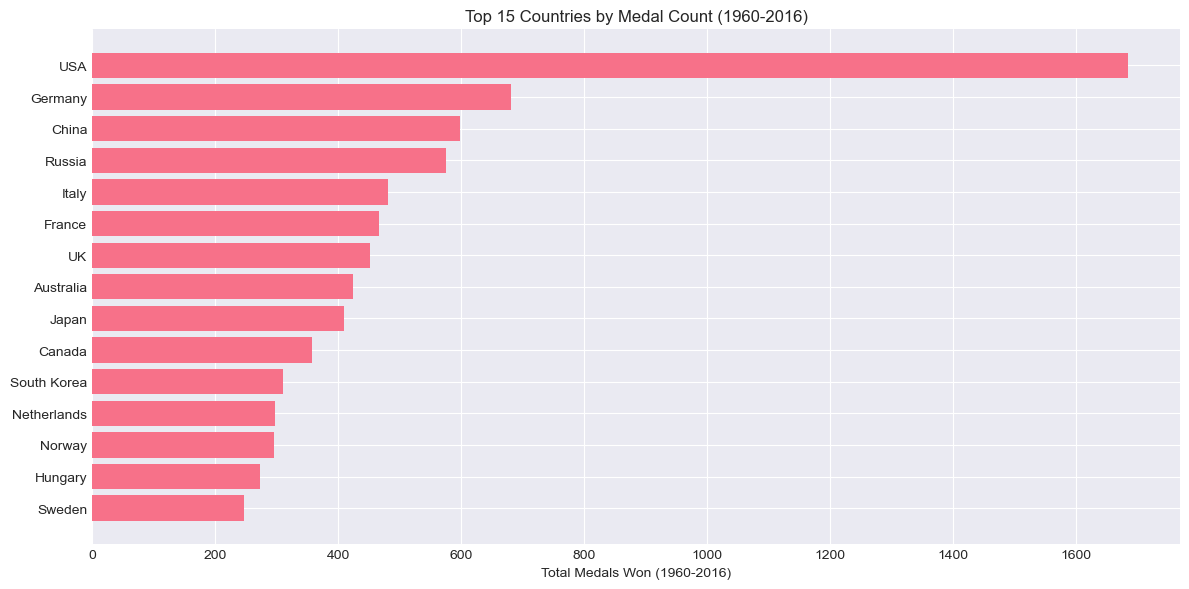


Total medals distributed: 10,644


In [4]:
medal_df = df_with_gdp[df_with_gdp['Medal_Won']].copy()

# Count unique medals per event
medal_unique = medal_df.groupby(
    ['Year', 'Country_Name', 'Sport', 'Event', 'Medal']
).size().reset_index(name='Count')

# Calculating total medals by country for the entire period
medal_counts = medal_unique.groupby('Country_Name').size().reset_index(name='Total_Medals')
medal_counts = medal_counts.sort_values('Total_Medals', ascending=False)
print("Top 20 Countries by Total Medals (1960-2016)")
print(medal_counts.head(20))

# Visualize top 15 countries
plt.figure(figsize=(12, 6))
top_15 = medal_counts.head(15)
plt.barh(range(len(top_15)), top_15['Total_Medals'])
plt.yticks(range(len(top_15)), top_15['Country_Name'])
plt.xlabel('Total Medals Won (1960-2016)')
plt.title('Top 15 Countries by Medal Count (1960-2016)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal medals distributed: {medal_counts['Total_Medals'].sum():,}")

Country Performance Statistics (countries with 100+ athletes)
    Country_Name       Avg_GDP  Total_Medals  Total_Athletes  \
118          USA  28401.367916          3658           12497   
42       Germany  29295.398191          1492            6845   
5      Australia  25917.347443          1173            6739   
92        Russia   7259.727120          1148            4862   
53         Italy  19207.249173          1004            7754   
22         China   4460.043514           993            5712   
18        Canada  24085.203110           974            8021   
117           UK  20825.125444           878            7397   
39        France  22115.465168           848            7580   
56         Japan  25120.724778           809            7295   
80   Netherlands  26731.484583           718            3852   
107       Sweden  25783.443595           639            4916   
103  South Korea  13186.820281           632            4341   
47       Hungary   5284.339094           5

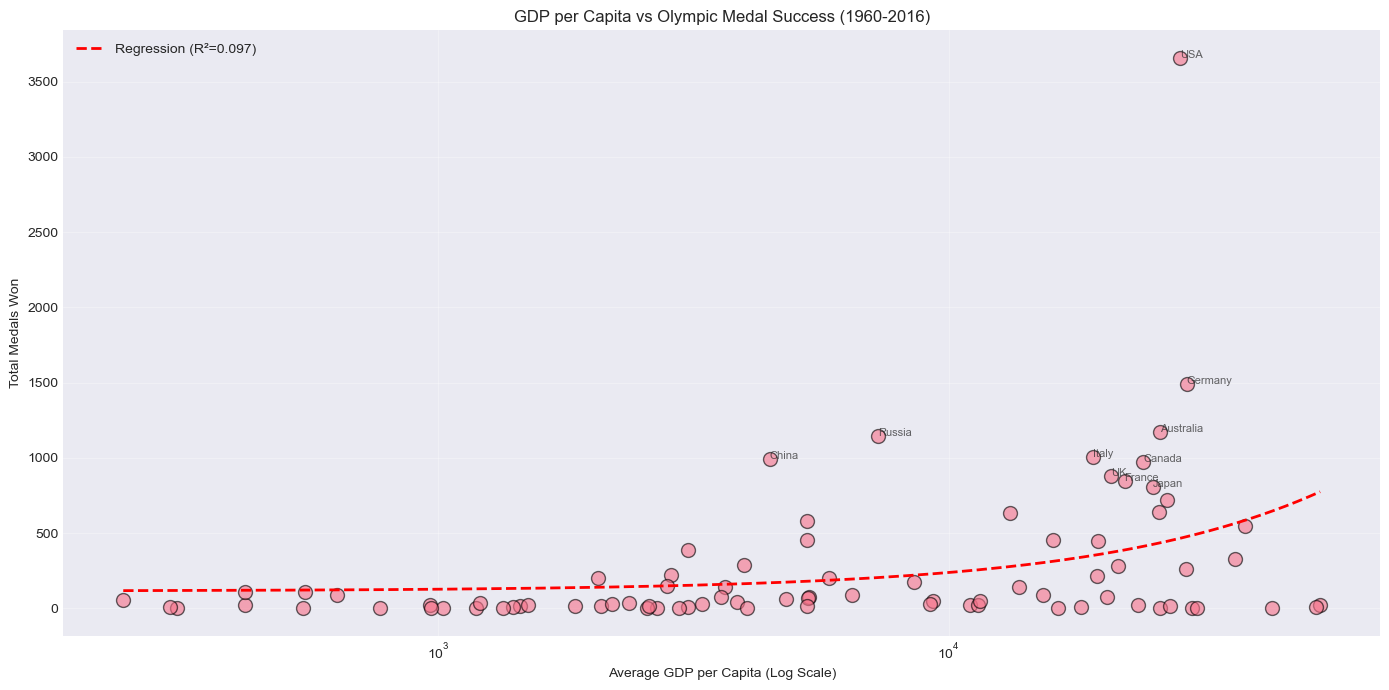

In [5]:
# Calculate average GDP and medal count by country
country_stats = df_with_gdp.groupby('Country_Name').agg({
    'GDP_per_capita': 'mean',
    'Medal_Won': 'sum',
    'Athlete_ID': 'count'
}).reset_index()

country_stats.columns = ['Country_Name', 'Avg_GDP', 'Total_Medals', 'Total_Athletes']

# Calculate medals per athlete (efficiency metric)
country_stats['Medals_per_Athlete'] = (
    country_stats['Total_Medals'] / country_stats['Total_Athletes'] * 100
).round(2)

# Remove countries with very few athletes (less than 100) for cleaner analysis
country_stats_filtered = country_stats[country_stats['Total_Athletes'] >= 100].copy()

print("Country Performance Statistics (countries with 100+ athletes)")
print(country_stats_filtered.sort_values('Total_Medals', ascending=False).head(20))

# Calculate correlation
correlation = country_stats_filtered[['Avg_GDP', 'Total_Medals']].corr()
print(f"\nCorrelation between Average GDP and Total Medals: {correlation.iloc[0,1]:.3f}")

# Linear regression using numpy

# Prepare regression variables
X = country_stats_filtered['Avg_GDP'].values
y = country_stats_filtered['Total_Medals'].values

# Fit regression line
slope, intercept = np.polyfit(X, y, 1)

# Predicted values
y_pred = slope * X + intercept

# Calculate R-squared manually
ss_total = np.sum((y - np.mean(y))**2)
ss_residual = np.sum((y - y_pred)**2)
r_squared = 1 - (ss_residual / ss_total)

print("Slope:", slope)
print("Intercept:", intercept)
print("R-squared:", round(r_squared, 4))

# Scatter plot + Regression
plt.figure(figsize=(14, 7))

plt.scatter(country_stats_filtered['Avg_GDP'], 
            country_stats_filtered['Total_Medals'],
            alpha=0.6, 
            s=100,
            edgecolor='black')

plt.xscale('log')

# Regression line
x_vals = np.linspace(country_stats_filtered['Avg_GDP'].min(),
                     country_stats_filtered['Avg_GDP'].max(), 200)

plt.plot(x_vals, slope * x_vals + intercept, 'r--', 
         linewidth=2,
         label=f'Regression (R²={r_squared:.3f})')

# Annotate top 10 countries by medal count
top_10_medals = country_stats_filtered.nlargest(10, 'Total_Medals')
for _, row in top_10_medals.iterrows():
    plt.annotate(row['Country_Name'], 
                 (row['Avg_GDP'], row['Total_Medals']),
                 fontsize=8, alpha=0.7)

plt.xlabel('Average GDP per Capita (Log Scale)')
plt.ylabel('Total Medals Won')
plt.title('GDP per Capita vs Olympic Medal Success (1960-2016)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Top 20 Most Efficient Countries (Medals per 100 Athletes)
    Country_Name  Total_Athletes  Total_Medals  Medals_per_Athlete  \
118          USA           12497          3658               29.27   
83      Pakistan             388           107               27.58   
92        Russia            4862          1148               23.61   
42       Germany            6845          1492               21.80   
98        Serbia             390            85               21.79   
25          Cuba            1937           389               20.08   
80   Netherlands            3852           718               18.64   
55       Jamaica             793           146               18.41   
5      Australia            6739          1173               17.41   
22         China            5712           993               17.38   
82        Norway            3242           549               16.93   
7     Azerbaijan             283            44               15.55   
47       Hungary            3759

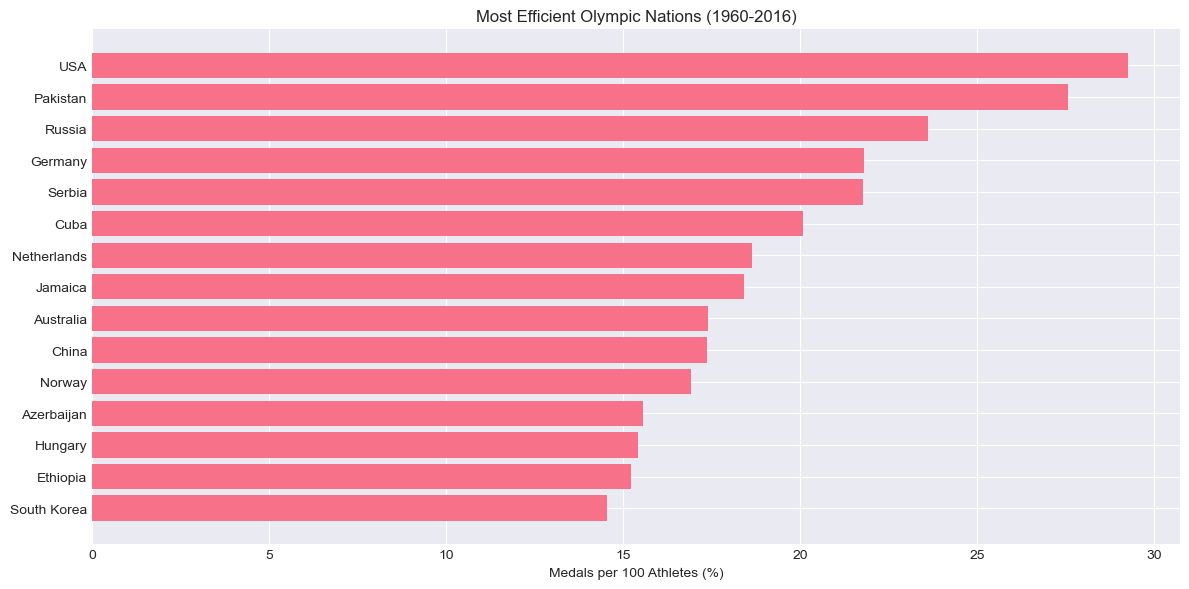

In [6]:
# Analyze medal efficiency - which countries are most efficient?
efficiency = country_stats_filtered.sort_values('Medals_per_Athlete', ascending=False)

print("Top 20 Most Efficient Countries (Medals per 100 Athletes)")
print(efficiency[['Country_Name', 'Total_Athletes', 'Total_Medals', 'Medals_per_Athlete', 'Avg_GDP']].head(20))

# Visualize top 15 most efficient countries
plt.figure(figsize=(12, 6))
top_15_eff = efficiency.head(15)
plt.barh(range(len(top_15_eff)), top_15_eff['Medals_per_Athlete'])
plt.yticks(range(len(top_15_eff)), top_15_eff['Country_Name'])
plt.xlabel('Medals per 100 Athletes (%)')
plt.title('Most Efficient Olympic Nations (1960-2016)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Medal Performance by GDP Category
                 Total_Medals         Country_Name
                          sum    mean        count
GDP_Category                                      
High GDP                12689  604.24           21
Low GDP                   722   34.38           21
Lower-Middle GDP         3515  167.38           21
Upper-Middle GDP         5003  238.24           21


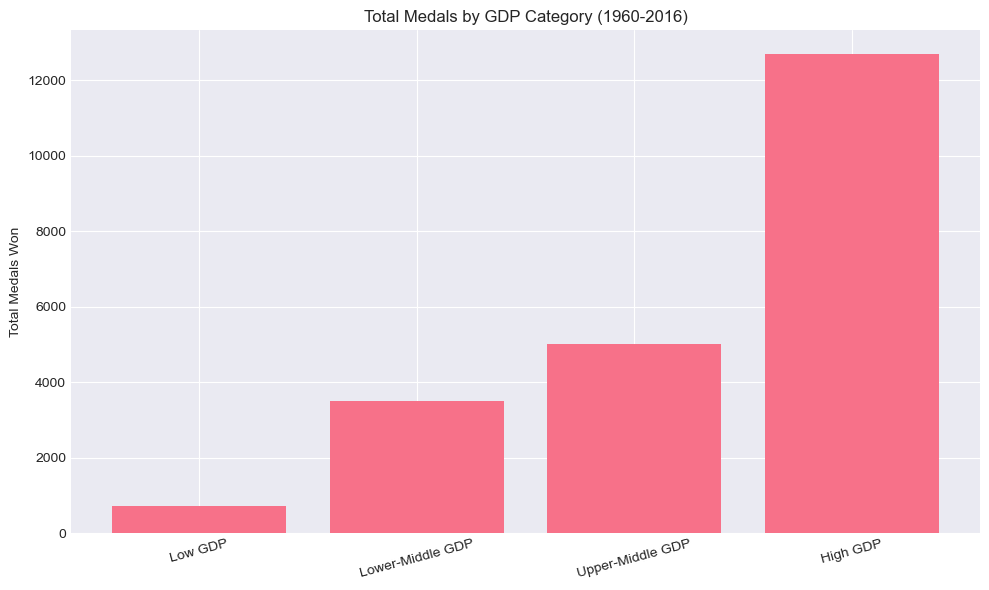

In [7]:
# Categorize countries by GDP level
gdp_quartiles = country_stats_filtered['Avg_GDP'].quantile([0.25, 0.5, 0.75])

def categorize_gdp(gdp):
    if gdp < gdp_quartiles[0.25]:
        return 'Low GDP'
    elif gdp < gdp_quartiles[0.5]:
        return 'Lower-Middle GDP'
    elif gdp < gdp_quartiles[0.75]:
        return 'Upper-Middle GDP'
    else:
        return 'High GDP'

country_stats_filtered['GDP_Category'] = country_stats_filtered['Avg_GDP'].apply(categorize_gdp)

# Analyze medal distribution by GDP category
gdp_category_stats = country_stats_filtered.groupby('GDP_Category').agg({
    'Total_Medals': ['sum', 'mean'],
    'Country_Name': 'count'
}).round(2)

print("Medal Performance by GDP Category")
print(gdp_category_stats)

# Visualize
category_order = ['Low GDP', 'Lower-Middle GDP', 'Upper-Middle GDP', 'High GDP']
gdp_category_medals = country_stats_filtered.groupby('GDP_Category')['Total_Medals'].sum().reindex(category_order)

plt.figure(figsize=(10, 6))
plt.bar(range(len(gdp_category_medals)), gdp_category_medals.values)
plt.xticks(range(len(gdp_category_medals)), gdp_category_medals.index, rotation=15)
plt.ylabel('Total Medals Won')
plt.title('Total Medals by GDP Category (1960-2016)')
plt.tight_layout()
plt.show()

Medal Count by Decade for Top Countries
Country_Name  Australia  China  France  Germany  Italy  Russia     UK    USA
Decade                                                                      
1960              141.0    0.0    89.0    224.0  191.0     0.0   77.0  502.0
1970               43.0    0.0    46.0      0.0   69.0     0.0   62.0  370.0
1980              100.0  126.0   131.0      0.0  142.0     0.0  175.0  605.0
1990              194.0  209.0   146.0    444.0  186.0   203.0   83.0  550.0
2000              493.0  388.0   226.0    481.0  257.0   597.0  199.0  958.0
2010              202.0  270.0   210.0    343.0  159.0   348.0  282.0  673.0


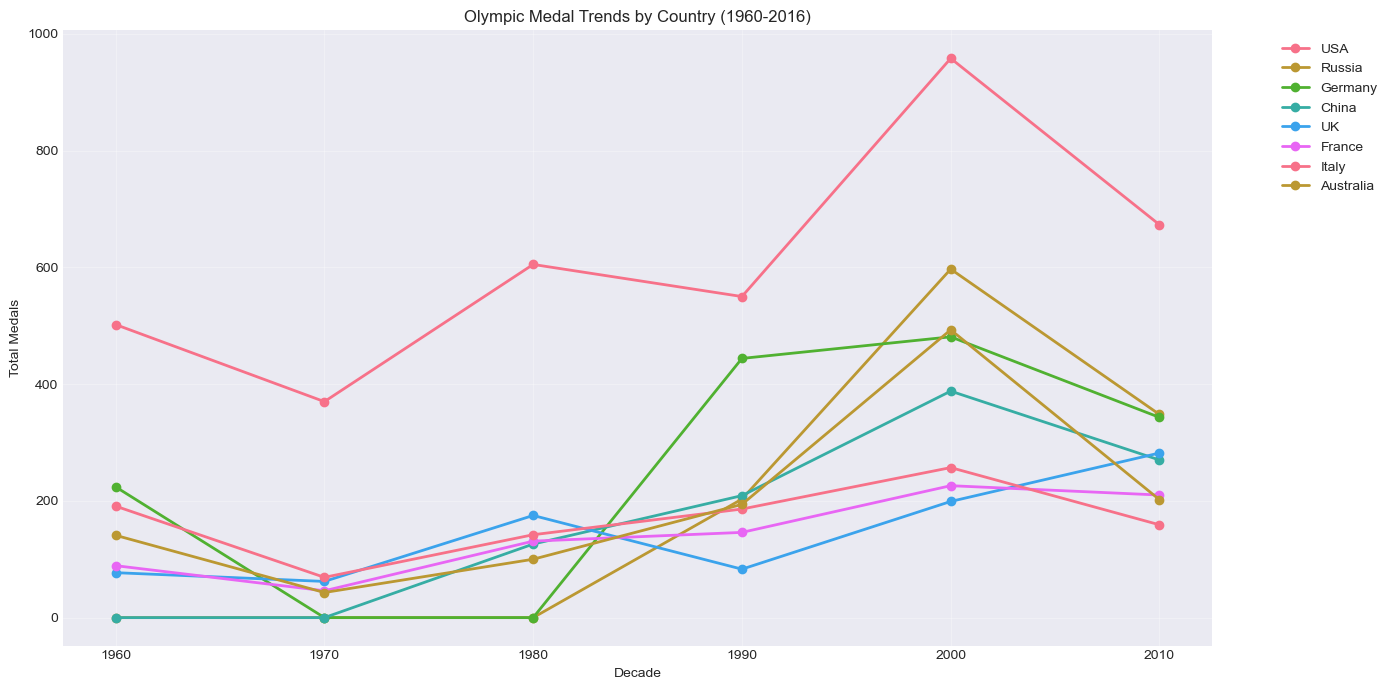

In [8]:
# Analyze how top countries' performance changed over decades
top_countries = ['USA', 'Russia', 'Germany', 'China', 'UK', 'France', 'Italy', 'Australia']

# Create decade bins
df_with_gdp['Decade'] = (df_with_gdp['Year'] // 10) * 10

# Medal count by country and decade
decade_medals = df_with_gdp[df_with_gdp['Country_Name'].isin(top_countries) & 
                            df_with_gdp['Medal_Won']].groupby(['Decade', 'Country_Name']).size().reset_index(name='Medals')

# Pivot for visualization
decade_pivot = decade_medals.pivot(index='Decade', columns='Country_Name', values='Medals').fillna(0)

print("Medal Count by Decade for Top Countries")
print(decade_pivot)

# Plot trends
plt.figure(figsize=(14, 7))
for country in top_countries:
    if country in decade_pivot.columns:
        plt.plot(decade_pivot.index, decade_pivot[country], marker='o', label=country, linewidth=2)

plt.xlabel('Decade')
plt.ylabel('Total Medals')
plt.title('Olympic Medal Trends by Country (1960-2016)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Medal Distribution by Sport and GDP Category
GDP_Category  Low GDP  Lower-Middle GDP  Upper-Middle GDP  High GDP
Sport                                                              
Athletics       200.0             338.0             314.0     964.0
Basketball        0.0              95.0             202.0     371.0
Canoeing         14.0             207.0             177.0     370.0
Cycling           6.0              22.0             152.0     492.0
Fencing          13.0             172.0             280.0     267.0
Football         38.0             201.0             137.0     349.0
Gymnastics       24.0             231.0             120.0     313.0
Handball         15.0              58.0             214.0     326.0
Hockey          179.0              16.0             236.0     622.0
Ice Hockey        0.0               0.0             262.0     653.0
Rowing           12.0             209.0             225.0    1025.0
Sailing          11.0              43.0             141.0     394.0
Swi

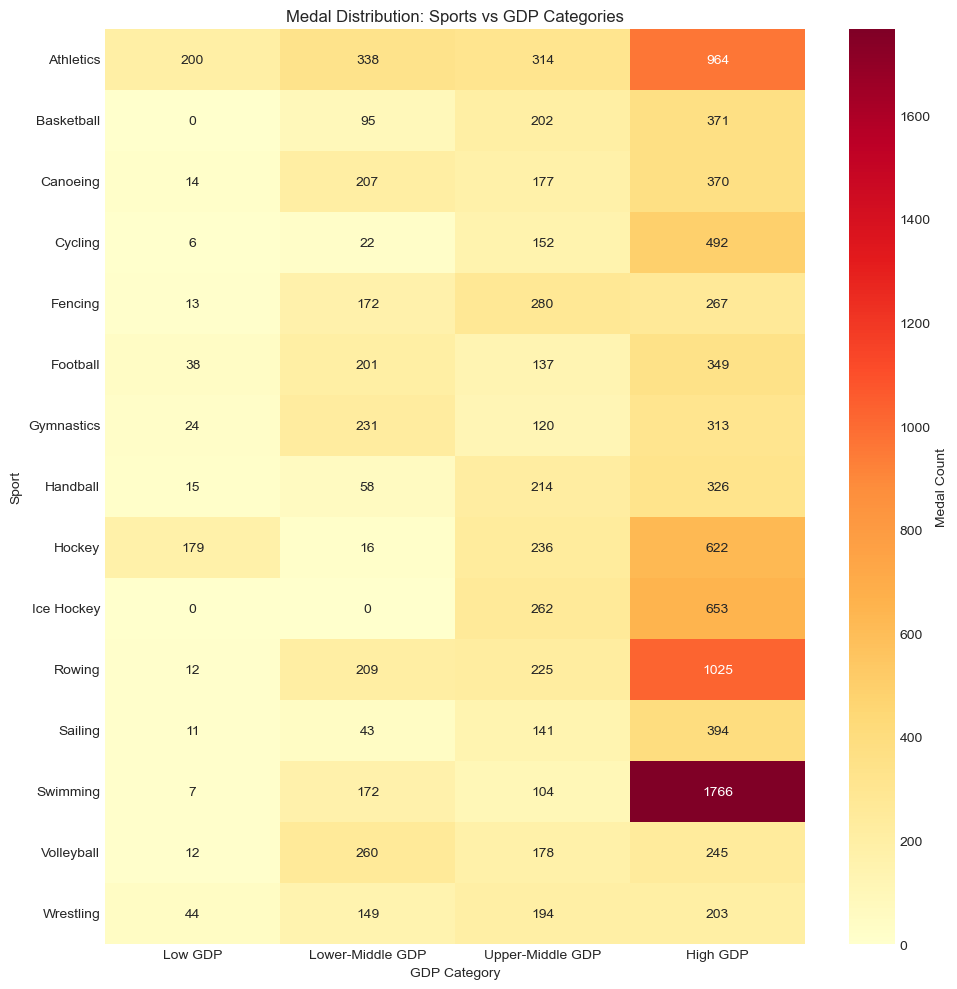

In [9]:
# Analyze which sports different GDP categories dominate
sport_gdp = df_with_gdp[df_with_gdp['Medal_Won']].copy()

# Merge with GDP categories
sport_gdp = sport_gdp.merge(
    country_stats_filtered[['Country_Name', 'GDP_Category']], 
    on='Country_Name', 
    how='left'
)

# Top 15 sports by medal count
top_sports = sport_gdp['Sport'].value_counts().head(15).index

# Medal distribution by sport and GDP category
sport_distribution = sport_gdp[sport_gdp['Sport'].isin(top_sports)].groupby(
    ['Sport', 'GDP_Category']
).size().reset_index(name='Medal_Count')

# Pivot for heatmap
sport_pivot = sport_distribution.pivot(index='Sport', columns='GDP_Category', values='Medal_Count').fillna(0)
sport_pivot = sport_pivot.reindex(columns=['Low GDP', 'Lower-Middle GDP', 'Upper-Middle GDP', 'High GDP'])

print("Medal Distribution by Sport and GDP Category")
print(sport_pivot)

# Heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(sport_pivot, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Medal Count'})
plt.title('Medal Distribution: Sports vs GDP Categories')
plt.xlabel('GDP Category')
plt.ylabel('Sport')
plt.tight_layout()
plt.show()

OVERPERFORMERS - Countries performing better than GDP predicts
    Country_Name       Avg_GDP  Total_Medals  Predicted_Medals  \
118          USA  28401.367916          3658        465.085411   
42       Germany  29295.398191          1492        476.126631   
92        Russia   7259.727120          1148        203.987438   
22         China   4460.043514           993        169.411517   
5      Australia  25917.347443          1173        434.407910   
53         Italy  19207.249173          1004        351.538606   
18        Canada  24085.203110           974        411.781040   
117           UK  20825.125444           878        371.519279   
39        France  22115.465168           848        387.454896   
47       Hungary   5284.339094           580        179.591517   
56         Japan  25120.724778           809        424.569669   
103  South Korea  13186.820281           632        277.186677   
14        Brazil   5267.715988           454        179.386222   
80   Netherla

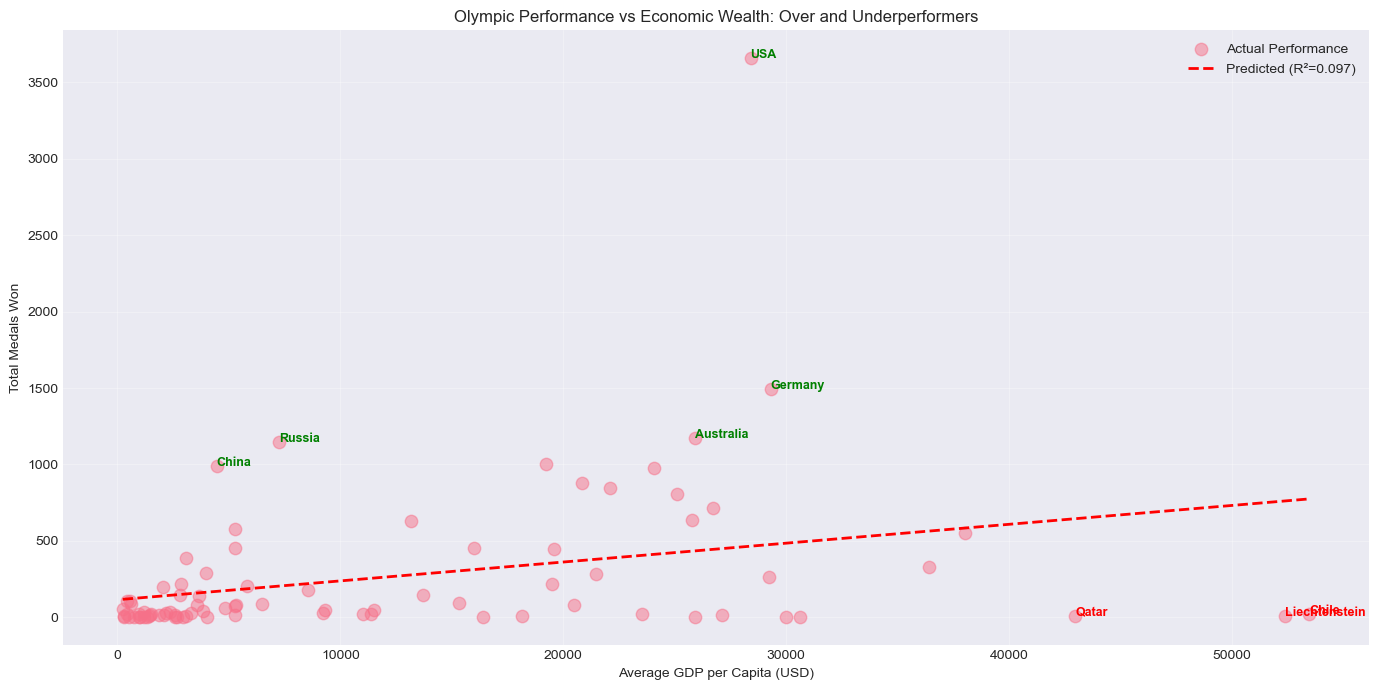

In [10]:
# Identify countries that perform better or worse than their GDP would predict
# Using linear regression to predict medals from GDP

from scipy import stats

# Prepare data for regression
X = country_stats_filtered['Avg_GDP'].values
y = country_stats_filtered['Total_Medals'].values

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)

# Predict medals based on GDP
country_stats_filtered['Predicted_Medals'] = slope * country_stats_filtered['Avg_GDP'] + intercept
country_stats_filtered['Medal_Difference'] = (country_stats_filtered['Total_Medals'] - 
                                               country_stats_filtered['Predicted_Medals'])
country_stats_filtered['Performance_Ratio'] = (country_stats_filtered['Total_Medals'] / 
                                                country_stats_filtered['Predicted_Medals'])

print("OVERPERFORMERS - Countries performing better than GDP predicts")
overperformers = country_stats_filtered.nlargest(15, 'Medal_Difference')
print(overperformers[['Country_Name', 'Avg_GDP', 'Total_Medals', 'Predicted_Medals', 'Medal_Difference']])

print("\nUNDERPERFORMERS - Countries performing worse than GDP predicts")
underperformers = country_stats_filtered.nsmallest(15, 'Medal_Difference')
print(underperformers[['Country_Name', 'Avg_GDP', 'Total_Medals', 'Predicted_Medals', 'Medal_Difference']])

# Visualize
plt.figure(figsize=(14, 7))
plt.scatter(country_stats_filtered['Avg_GDP'], 
            country_stats_filtered['Total_Medals'],
            alpha=0.5, s=80, label='Actual Performance')

# Plot regression line
x_line = np.linspace(country_stats_filtered['Avg_GDP'].min(), 
                     country_stats_filtered['Avg_GDP'].max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, 'r--', linewidth=2, label=f'Predicted (R²={r_value**2:.3f})')

# Annotate overperformers
for idx, row in overperformers.head(5).iterrows():
    plt.annotate(row['Country_Name'], 
                 (row['Avg_GDP'], row['Total_Medals']),
                 fontsize=9, color='green', fontweight='bold')

# Annotate underperformers
for idx, row in underperformers.head(3).iterrows():
    plt.annotate(row['Country_Name'], 
                 (row['Avg_GDP'], row['Total_Medals']),
                 fontsize=9, color='red', fontweight='bold')

plt.xlabel('Average GDP per Capita (USD)')
plt.ylabel('Total Medals Won')
plt.title('Olympic Performance vs Economic Wealth: Over and Underperformers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()